# Tukey HSD Multi-Category Test


In [1]:
# Setup environment path (to act like the script's entry point)
import sys
import os
from pathlib import Path

# Jupyter sets cwd to the directory of the notebook.
cwd = Path.cwd().resolve()
if cwd.name == "statistics_tests":
    os.chdir(cwd.parents[3])  # Go to project root (anaconda_research_project)
    print(f"Changed working directory to project root: {Path.cwd()}")

# Add necessary paths (simulating the script's behavior)
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
SEABORN_ROOT = PROJECT_ROOT / "scripts" / "report" / "seaborn_script"
if str(SEABORN_ROOT) not in sys.path:
    sys.path.insert(0, str(SEABORN_ROOT))


Changed working directory to project root: D:\Work\Research_Project\anaconda_research_project


In [2]:
import re
from typing import Dict, List, Optional, Tuple, Sequence, Any
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from settings import apply_paper_fmt
from helpers.draw import (
    center_x_axis_at_zero,
    color_tukey_by_categorized_taxonomy,
    load_categorized_lang_taxonomy,
    normalize_categorized_language,
)
from helpers.lang_profiles import get_langs
from scripts.csv_helpers import bump_field_limit
from helpers.output_writer import write_df


In [3]:
ALPHA = 0.25
LABELS = [0, 1, 2, 3]
METRIC = "mean_diff"

# ==========================================================
# Category configuration
# - baseline/raw are automatically included
# - add one entry per non-baseline category
# - each category can match one or more suffixes
# ==========================================================
CATEGORY_CONFIGS: List[Dict[str, Any]] = [
    {
        "name": "_first",
        "label": "First QP",
        "marker": "x",
        "suffixes": ("_first",),
        "extra_strip_suffixes": ("_first",),
    },
    {
        "name": "_last",
        "label": "Last QP",
        "marker": "s",
        "suffixes": ("_last",),
        "extra_strip_suffixes": ("_last",),
    },
]

BASELINE_LABEL = "Rand QP"
BASELINE_MARKER = "^"

ALL_CATEGORY_SUFFIXES: Tuple[str, ...] = tuple(
    suf
    for cfg in CATEGORY_CONFIGS
    for suf in cfg["suffixes"]
)
ALL_EXTRA_STRIP_SUFFIXES: Tuple[str, ...] = tuple(
    suf
    for cfg in CATEGORY_CONFIGS
    for suf in cfg.get("extra_strip_suffixes", ())
)

BASE_LANGS: List[str] = [
    "raw", "eng", "ar", "vi", "th", "fr", "ru", "he", "sw", "ga", "hi", "zh"
]

# BASE_LANGS: 
# BASE_LANGS: List[str] = get_langs(BASE_LANG_PROFILE)

# Keep raw + baseline languages, then add all configured category variants.
LANGS: List[str] = []
for lang in BASE_LANGS:
    if lang not in LANGS:
        LANGS.append(lang)

for cfg in CATEGORY_CONFIGS:
    for lang in BASE_LANGS:
        if lang == "raw":
            continue
        if any(lang.endswith(suf) for suf in ALL_CATEGORY_SUFFIXES):
            base_lang = normalize_categorized_language(
                lang,
                category_suffixes=ALL_CATEGORY_SUFFIXES,
                extra_strip_suffixes=ALL_EXTRA_STRIP_SUFFIXES,
                base_len=2,
            )
        else:
            base_lang = lang
        for suffix in cfg["suffixes"]:
            candidate = f"{base_lang}{suffix}"
            if candidate not in LANGS:
                LANGS.append(candidate)


In [4]:
LANG_PROFILE = "position"

# =========================
# Config
# =========================
TREC_DL_YEAR = "2021"
LABEL_ROOT = Path("outputs/llm_label") / f"trec_dl_{TREC_DL_YEAR}"
OUT_DIR = Path("figures") / TREC_DL_YEAR / "tukey_hsd" / f"all_models_all_{LANG_PROFILE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_TUKEY_CSV = OUT_DIR / "tukey_hsd_table_all_groups.csv"
OUT_TUKEY_TEX = OUT_DIR / "tukey_hsd_table_all_groups.tex"
OUT_SIMUL_SVG = OUT_DIR / f"tukey_hsd_plot_simultaneous_all_groups_{TREC_DL_YEAR}.svg"
OUT_SIMUL_PDF = OUT_DIR / f"tukey_hsd_plot_simultaneous_all_groups_{TREC_DL_YEAR}.pdf"
OUT_SAMPLES = OUT_DIR / "tukey_samples_long.csv"

INVALID_CSV = (SEABORN_ROOT / "statistics_tests") / f"invalid_{TREC_DL_YEAR}.csv"
KEY_COLS = ["qid", "pid"]

GROUP_SEP = "|"
TAXONOMY_CSV = SEABORN_ROOT / "lang.csv"

In [5]:
def find_llm_files() -> Dict[str, List[Path]]:
    """
    Returns model -> list of label CSVs.
    Expected layout:
      outputs/llm_label/trec_dl_<YEAR>/<MODEL>/<MODEL>_trecdl_<YEAR>_<LANG>_labels.csv
    """
    if not LABEL_ROOT.exists():
        raise FileNotFoundError(f"LABEL_ROOT not found: {LABEL_ROOT}")

    model_files: Dict[str, List[Path]] = {}
    for model_dir in LABEL_ROOT.iterdir():
        if not model_dir.is_dir():
            continue

        model_name = model_dir.name
        csv_files = list(model_dir.glob(f"{model_name}_trecdl_{TREC_DL_YEAR}_*_labels.csv"))

        if csv_files:
            model_files[model_name] = csv_files
        else:
            print(f"Warning: no label CSVs found for model {model_name} in {model_dir}")

    return model_files


def get_lang_from_filename(file_path: Path, model: str) -> Optional[str]:
    """
    Extract <LANG> from:
      <MODEL>_trecdl_<YEAR>_<LANG>_labels.csv
    """
    fname = file_path.name
    pattern = rf"^{re.escape(model)}_trecdl_\d{{4}}_(.+?)_labels\.csv$"
    match = re.search(pattern, fname)
    return match.group(1) if match else None


def load_labels(file_path: Path, invalid_keys: set[tuple[int, str]]) -> pd.DataFrame:
    bump_field_limit()
    df = pd.read_csv(file_path)

    requisite = {"qid", "pid", "relevance", "llm_relevance"}
    missing = requisite - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns {sorted(missing)} in {file_path}")

    df["NIST"] = pd.to_numeric(df["relevance"], errors="coerce")
    df["LLM"] = pd.to_numeric(df["llm_relevance"], errors="coerce")

    df = df.dropna(subset=["NIST", "LLM"]).copy()
    df["NIST"] = df["NIST"].astype(int)
    df["LLM"] = df["LLM"].astype(int)
    df = df[df["NIST"].isin(LABELS) & df["LLM"].isin(LABELS)].copy()

    df = df.dropna(subset=["qid", "pid"]).copy()
    df["qid"] = pd.to_numeric(df["qid"], errors="coerce")
    df = df.dropna(subset=["qid"]).copy()
    df["qid"] = df["qid"].astype(int)
    df["pid"] = df["pid"].astype(str)

    if invalid_keys:
        keys = pd.Index(list(zip(df["qid"].to_numpy(), df["pid"].to_numpy())))
        df = df[~keys.isin(invalid_keys)].copy()

    return df


def per_row_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Turn a (qid,pid)-level label dataframe into per-row samples:
      qid, pid, value
    """
    base = df.dropna(subset=["qid", "pid"]).drop_duplicates(subset=["qid", "pid"]).copy()

    if metric == "mean_diff":
        base["value"] = base["LLM"] - base["NIST"]
        return base[["qid", "pid", "value"]]

    if metric == "mae_4pt":
        base["value"] = (base["LLM"] - base["NIST"]).abs()
        return base[["qid", "pid", "value"]]

    if metric == "disagree_rate":
        base["value"] = (base["LLM"] != base["NIST"]).astype(float)
        return base[["qid", "pid", "value"]]

    raise ValueError("Unknown METRIC. Use 'mean_diff', 'mae_4pt', or 'disagree_rate'.")


def load_invalid_keys(path: Path) -> set[tuple[int, str]]:
    """
    Loads invalid (qid,pid) pairs from invalid_YYYY.csv.
    """
    if not path.exists():
        print(f"[INFO] No invalid file found: {path}")
        return set()

    inv = pd.read_csv(path)
    if not set(KEY_COLS).issubset(inv.columns):
        raise ValueError(f"{path} must contain columns {KEY_COLS}")

    inv = inv.dropna(subset=KEY_COLS).copy()
    inv["qid"] = pd.to_numeric(inv["qid"], errors="coerce")
    inv = inv.dropna(subset=["qid"])
    inv["qid"] = inv["qid"].astype(int)
    inv["pid"] = inv["pid"].astype(str)

    keys = set(inv[KEY_COLS].drop_duplicates().itertuples(index=False, name=None))
    print(f"[INFO] Loaded {len(keys)} invalid keys from {path}")
    return keys


# =========================
# Tukey helpers
# =========================


In [6]:
def safe_slug(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return s.strip("_")


def tukey_to_df(tukey) -> pd.DataFrame:
    table = tukey.summary().data
    header = table[0]
    body = table[1:]
    df = pd.DataFrame(body, columns=header)

    for c in ["meandiff", "p-adj", "lower", "upper"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "reject" in df.columns:
        df["reject"] = (
            df["reject"].astype(str).str.lower().map({"true": True, "false": False})
        )

    return df


def to_latex_table(df: pd.DataFrame, caption: str, label: str) -> str:
    fmt = df.copy()

    for c in ["meandiff", "p-adj", "lower", "upper"]:
        if c in fmt.columns:
            fmt[c] = fmt[c].map(lambda x: f"{x:.6g}" if pd.notnull(x) else "")

    return fmt.to_latex(
        index=False,
        escape=False,
        caption=caption,
        label=label,
        column_format="l l r r r r l",
    )


def split_group(group: str, group_sep: str = GROUP_SEP) -> Tuple[str, str]:
    if group_sep in group:
        return tuple(group.split(group_sep, 1))  # type: ignore[return-value]
    return "", group


def is_raw_lang(lang: str, *, group_sep: str = GROUP_SEP) -> bool:
    s = str(lang).strip().lower()
    if group_sep in s:
        s = s.split(group_sep, 1)[1]
    return s == "raw"


def get_category_config(
    lang: str,
    *,
    category_configs: Sequence[Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    s = str(lang).strip().lower()
    for cfg in category_configs:
        if any(s.endswith(suf.lower()) for suf in cfg["suffixes"]):
            return cfg
    return None


def is_categorized_lang(
    lang: str,
    *,
    category_configs: Sequence[Dict[str, Any]],
) -> bool:
    return get_category_config(lang, category_configs=category_configs) is not None


def pretty_lang_label(
    lang: str,
    *,
    group_sep: str = GROUP_SEP,
    category_suffixes: Sequence[str],
    extra_strip_suffixes: Sequence[str],
) -> str:
    s = str(lang).strip().lower()

    if group_sep in s:
        s = s.split(group_sep, 1)[1]

    if s == "raw":
        return ""

    base = normalize_categorized_language(
        s,
        group_sep=group_sep,
        category_suffixes=category_suffixes,
        extra_strip_suffixes=extra_strip_suffixes,
        base_len=2,
    )
    return base.upper()


def build_group_metadata(
    groups: List[str],
    *,
    taxonomy_csv: Path,
    group_sep: str,
    category_configs: Sequence[Dict[str, Any]],
    category_suffixes: Sequence[str],
    extra_strip_suffixes: Sequence[str],
) -> pd.DataFrame:
    rows = []
    for group in groups:
        model, lang = split_group(group, group_sep=group_sep)
        cfg = get_category_config(lang, category_configs=category_configs)

        base_lang = normalize_categorized_language(
            lang,
            group_sep=group_sep,
            category_suffixes=category_suffixes,
            extra_strip_suffixes=extra_strip_suffixes,
            base_len=2,
        )

        is_raw = str(lang).strip().lower() == "raw"

        rows.append(
            {
                "group": group,
                "model": model,
                "lang": lang,
                "base_lang": base_lang,
                "label": pretty_lang_label(
                    lang,
                    group_sep=group_sep,
                    category_suffixes=category_suffixes,
                    extra_strip_suffixes=extra_strip_suffixes,
                ),
                "is_category": cfg is not None,
                "category_name": None if cfg is None else cfg["name"],
                "category_label": None if cfg is None else cfg["label"],
                "category_marker": None if cfg is None else cfg["marker"],
                "category_order": 0 if cfg is None else (
                    next(i for i, c in enumerate(category_configs, start=1) if c["name"] == cfg["name"])
                ),
                "is_raw": is_raw,
                "tax_key": base_lang,
            }
        )

    meta = pd.DataFrame(rows).drop_duplicates()

    lang_to_level = load_categorized_lang_taxonomy(
        taxonomy_csv,
        category_suffixes=category_suffixes,
        extra_strip_suffixes=extra_strip_suffixes,
        base_len=2,
    )
    meta["taxonomy_level"] = meta["tax_key"].map(lang_to_level).fillna(999).astype(int)

    meta = meta.sort_values(
        by=["model", "taxonomy_level", "base_lang", "category_order"],
        ascending=[True, True, True, True],
    ).reset_index(drop=True)

    visible = meta[~meta["is_raw"]].copy()

    row_df = (
        visible[["model", "base_lang", "label", "taxonomy_level"]]
        .drop_duplicates()
        .sort_values(by=["model", "taxonomy_level", "base_lang"])
        .reset_index(drop=True)
    )

    model_gap = 2.0

    ys = []
    y = 0.0
    prev_model = None

    for _, row in row_df.iterrows():
        model = row["model"]
        if prev_model is not None and model != prev_model:
            y += model_gap
        ys.append(y)
        y += 1.0
        prev_model = model

    row_df["y"] = ys

    meta = meta.merge(
        row_df[["model", "base_lang", "label", "y"]],
        on=["model", "base_lang", "label"],
        how="left",
    )

    return meta


def add_multi_category_legend(
    ax,
    *,
    level_to_rgba: Dict[int, Any],
    category_configs: Sequence[Dict[str, Any]],
    baseline_label: str,
    baseline_marker: str,
    taxonomy_title: str = "Resource level",
    category_title: str = "Variant",
    taxonomy_loc: str = "upper right",
    category_loc: str = "lower right",
) -> None:
    taxonomy_handles = []
    for level in sorted(level_to_rgba):
        if level == 999:
            continue
        taxonomy_handles.append(
            Line2D([0], [0], color=level_to_rgba[level], lw=2.5, label=f"Level {level}")
        )

    if taxonomy_handles:
        leg1 = ax.legend(
            handles=taxonomy_handles,
            title=taxonomy_title,
            loc=taxonomy_loc,
            frameon=True,
        )
        ax.add_artist(leg1)

    variant_handles = [
        Line2D(
            [0],
            [0],
            marker=baseline_marker,
            linestyle="None",
            color="black",
            markersize=9,
            label=baseline_label,
        )
    ]

    for cfg in category_configs:
        variant_handles.append(
            Line2D(
                [0],
                [0],
                marker=cfg["marker"],
                linestyle="None",
                color="black",
                markersize=9,
                markeredgewidth=2.0 if cfg["marker"] in {"x", "+", "X"} else 1.2,
                label=cfg["label"],
            )
        )

    ax.legend(
        handles=variant_handles,
        title=category_title,
        loc=category_loc,
        frameon=True,
    )


In [7]:
def plot_simultaneous_collapsed_same_row(
    tukey,
    ax,
    *,
    taxonomy_csv: Path,
    category_configs: Sequence[Dict[str, Any]],
    category_suffixes: Sequence[str],
    extra_strip_suffixes: Sequence[str] = ("_wo",),
    baseline_marker: str = "^",
    group_sep: str = GROUP_SEP,
    model_x: float = -0.08,
    raw_band_alpha: float = 0.22,
    raw_band_color: str = "#7ec8e3",
) -> None:
    """
    Plot Tukey simultaneous CIs so that:
      - each base language gets one shared row
      - RAW is not shown as a row or datapoint
      - RAW is shown as a vertical shaded CI band spanning the full height
        of its model block
      - baseline and each configured category use separate markers
    """
    groups_unique = list(tukey.groupsunique)
    meta = build_group_metadata(
        groups_unique,
        taxonomy_csv=taxonomy_csv,
        group_sep=group_sep,
        category_configs=category_configs,
        category_suffixes=category_suffixes,
        extra_strip_suffixes=extra_strip_suffixes,
    )

    means = tukey._multicomp.groupstats.groupmean
    tukey._simultaneous_ci()
    halfwidths = tukey.halfwidths

    group_to_mean = dict(zip(groups_unique, means))
    group_to_halfwidth = dict(zip(groups_unique, halfwidths))

    row_df = (
        meta[~meta["is_raw"]][["model", "label", "y"]]
        .drop_duplicates()
        .sort_values("y")
        .reset_index(drop=True)
    )

    group_to_y = {
        row["group"]: row["y"]
        for _, row in meta[~meta["is_raw"]].iterrows()
    }

    model_blocks = []
    for model, sub in row_df.groupby("model", sort=False):
        ys = sub["y"].tolist()
        if ys:
            model_blocks.append((model, min(ys), max(ys)))

    model_to_block = {model: (y0, y1) for model, y0, y1 in model_blocks}

    for group in groups_unique:
        model, lang = split_group(group, group_sep=group_sep)

        if not is_raw_lang(lang, group_sep=group_sep):
            continue

        if model not in model_to_block:
            continue

        mean = group_to_mean[group]
        halfwidth = group_to_halfwidth[group]
        left = mean - halfwidth
        right = mean + halfwidth

        y0, y1 = model_to_block[model]
        ymin = y0 - 0.5
        ymax = y1 + 0.5

        ax.fill_betweenx(
            [ymin, ymax],
            left,
            right,
            color=raw_band_color,
            alpha=raw_band_alpha,
            linewidth=0,
            zorder=0,
        )

    meta_index = meta.set_index("group")

    for group in groups_unique:
        _, lang = split_group(group, group_sep=group_sep)

        if is_raw_lang(lang, group_sep=group_sep):
            continue

        y = group_to_y[group]
        mean = group_to_mean[group]
        halfwidth = group_to_halfwidth[group]

        left = mean - halfwidth
        right = mean + halfwidth

        row = meta_index.loc[group]
        marker = baseline_marker if not row["is_category"] else row["category_marker"]

        ax.hlines(y, left, right, color="black", linewidth=1.4, zorder=2)
        ax.plot(
            mean,
            y,
            marker=marker,
            linestyle="None",
            color="black",
            markersize=11.0,
            markeredgewidth=2.0 if marker in {"x", "+", "X"} else 1.2,
            zorder=3,
        )

    ax.set_yticks(row_df["y"].tolist())
    ax.set_yticklabels(row_df["label"].tolist())

    for i in range(len(model_blocks) - 1):
        _, _, y1 = model_blocks[i]
        _, y2, _ = model_blocks[i + 1]
        sep_y = (y1 + y2) / 2.0
        ax.axhline(y=sep_y, linewidth=1.2, alpha=0.8, color="black")

    trans = ax.get_yaxis_transform()
    for model, y0, y1 in model_blocks:
        ymid = (y0 + y1) / 2.0
        ax.text(
            model_x,
            ymid,
            model,
            transform=trans,
            rotation=90,
            va="center",
            ha="right",
            fontweight="bold",
        )

    ax.invert_yaxis()

# =========================
# Main
# =========================


[INFO] Loaded 6 invalid keys from D:\Work\Research_Project\anaconda_research_project\scripts\report\seaborn_script\statistics_tests\invalid_2021.csv
Found 3 models under: outputs\llm_label\trec_dl_2021
[INFO] gpt-oss-20b ar_first: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b ar: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b ar_last: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b eng_first: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b eng: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b eng_last: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b fr_first: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b fr: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b fr_last: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b ga_first: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b ga: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b ga_last: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b he_first: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b he: 2390 valid (qid,pid) pairs
[INFO] gpt-oss-20b he_last: 2390 valid (qid,p

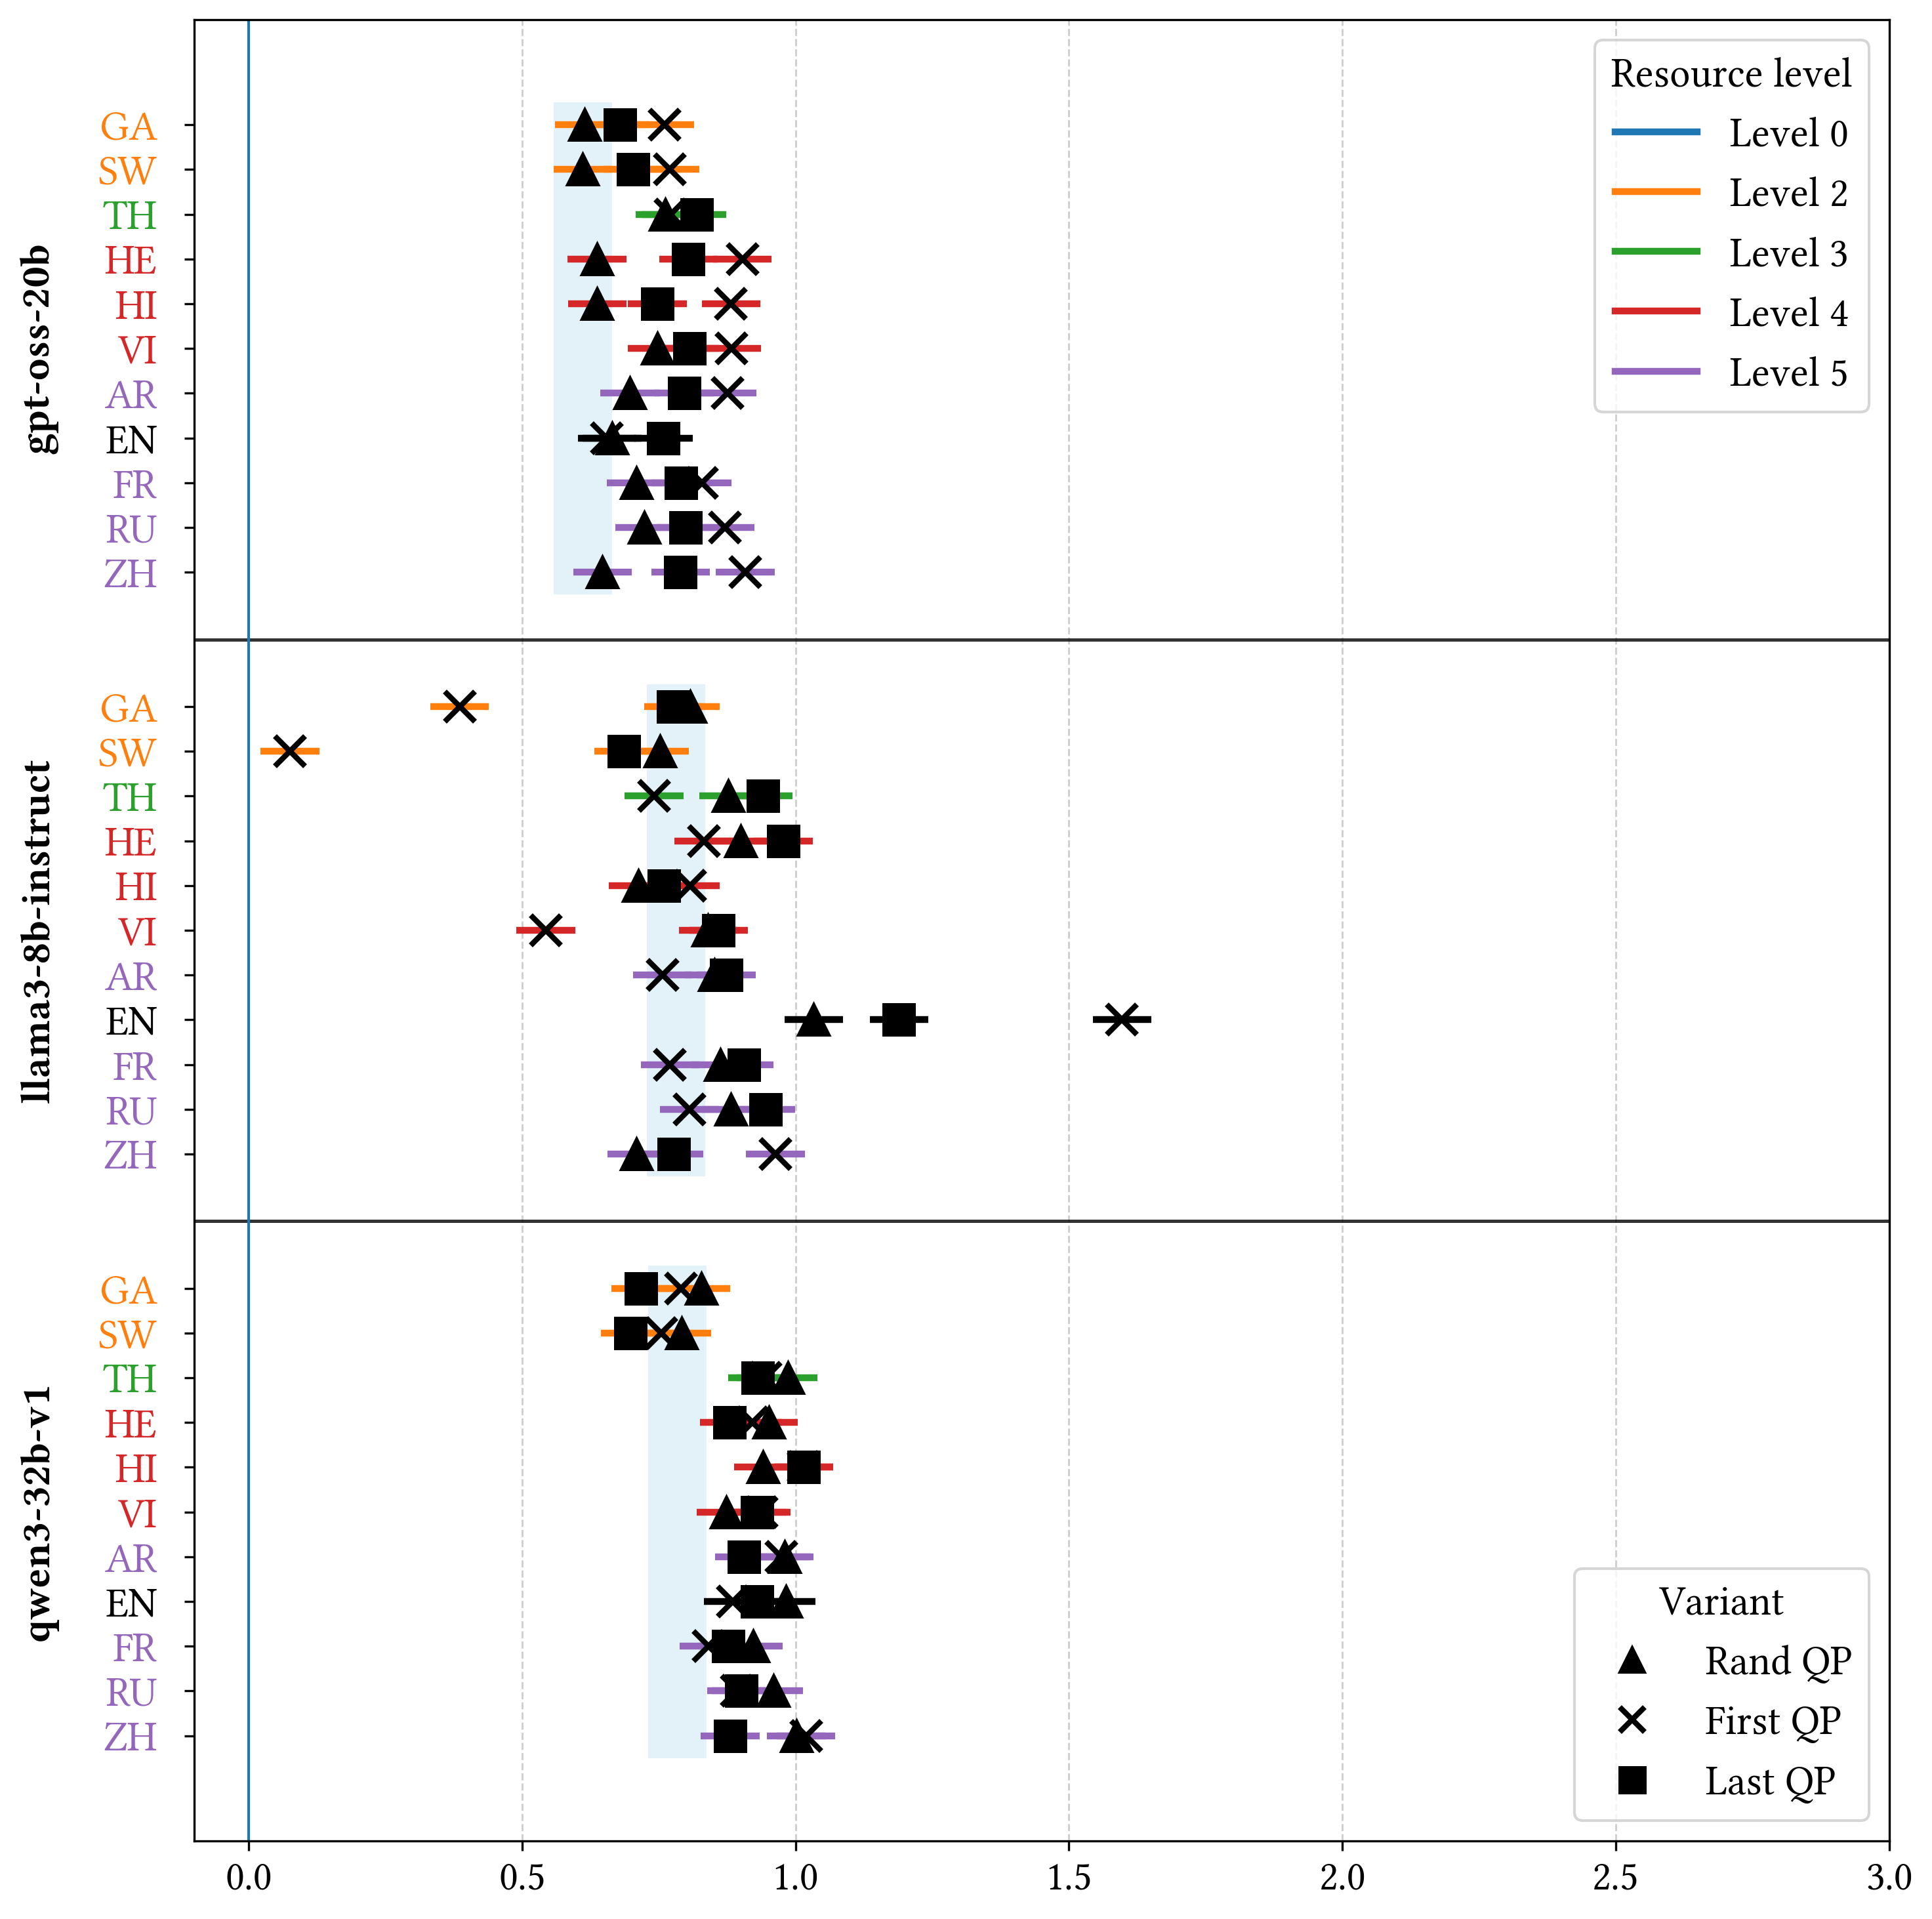


[OK] Wrote samples: figures\2021\tukey_hsd\all_models_all_position\tukey_samples_long.csv
[OK] Wrote Tukey CSV: figures\2021\tukey_hsd\all_models_all_position\tukey_hsd_table_all_groups.csv
[OK] Wrote Tukey TeX: figures\2021\tukey_hsd\all_models_all_position\tukey_hsd_table_all_groups.tex
[OK] Wrote plot: figures\2021\tukey_hsd\all_models_all_position\tukey_hsd_plot_simultaneous_all_groups_2021.svg


In [8]:
model_files = find_llm_files()
invalid_keys = load_invalid_keys(INVALID_CSV)
print(f"Found {len(model_files)} models under: {LABEL_ROOT}")

rows: List[pd.DataFrame] = []
skipped = 0

for model, files in model_files.items():
    for f in files:
        lang = get_lang_from_filename(f, model)

        if lang not in LANGS:
            continue

        try:
            df = load_labels(f, invalid_keys)
            pair_count = (
                df.dropna(subset=["qid", "pid"])
                .drop_duplicates(subset=["qid", "pid"])
                .shape[0]
            )
            print(f"[INFO] {model} {lang}: {pair_count} valid (qid,pid) pairs")

            perrow = per_row_metric(df, METRIC)
            if perrow.empty:
                continue

            perrow["model"] = model
            perrow["lang"] = lang
            perrow["group"] = perrow["model"] + GROUP_SEP + perrow["lang"]

            rows.append(perrow[["group", "model", "lang", "qid", "pid", "value"]])

        except Exception as e:
            skipped += 1
            print(f"[SKIP] {model} {lang} ({f.name}): {e}")

if not rows:
    raise RuntimeError(
        f"No samples produced. Check LABEL_ROOT={LABEL_ROOT}, LANGS={LANGS}, and file schemas."
    )

long_df = pd.concat(rows, ignore_index=True)

counts = long_df["group"].value_counts()
keep_groups = counts[counts >= 2].index
dropped = [g for g in counts.index if g not in set(keep_groups)]
long_df = long_df[long_df["group"].isin(keep_groups)].copy()

group_count = long_df["group"].nunique()
if group_count < 2:
    raise RuntimeError("Not enough (model,lang) groups with >=2 samples to run Tukey.")

write_df(long_df, OUT_SAMPLES)
if dropped:
    print(f"[INFO] Dropped {len(dropped)} groups with <2 qid samples.")

tukey = pairwise_tukeyhsd(
    endog=long_df["value"].to_numpy(),
    groups=long_df["group"].to_numpy(),
    alpha=ALPHA,
)

tukey_df = tukey_to_df(tukey)
write_df(tukey_df, OUT_TUKEY_CSV)

latex = to_latex_table(
    tukey_df,
    caption=f"Tukey HSD across all (model,lang) groups for {METRIC}, FWER={ALPHA}.",
    label=f"tab:tukey_all_models_all_langs_{safe_slug(METRIC)}",
)
OUT_TUKEY_TEX.write_text(latex, encoding="utf-8")

# Plot
apply_paper_fmt()
fig, ax = plt.subplots(figsize=(10, 10))

plot_simultaneous_collapsed_same_row(
    tukey,
    ax,
    taxonomy_csv=TAXONOMY_CSV,
    category_configs=CATEGORY_CONFIGS,
    category_suffixes=ALL_CATEGORY_SUFFIXES,
    extra_strip_suffixes=ALL_EXTRA_STRIP_SUFFIXES,
    baseline_marker=BASELINE_MARKER,
    group_sep=GROUP_SEP,
    model_x=-0.08,
)

level_palette = color_tukey_by_categorized_taxonomy(
    fig,
    ax,
    taxonomy_csv=TAXONOMY_CSV,
    category_suffixes=ALL_CATEGORY_SUFFIXES,
    extra_strip_suffixes=ALL_EXTRA_STRIP_SUFFIXES,
    group_sep=GROUP_SEP,
    default_level=0,
    linewidth=2.5,
)

add_multi_category_legend(
    ax,
    level_to_rgba=level_palette,
    category_configs=CATEGORY_CONFIGS,
    baseline_label=BASELINE_LABEL,
    baseline_marker=BASELINE_MARKER,
    taxonomy_title="Resource level",
    category_title="Variant",
    taxonomy_loc="upper right",
    category_loc="lower right",
)

center_x_axis_at_zero(ax)
ax.set_xlim(-0.1, 3.0)
ax.tick_params(axis="y", pad=10)

ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)
ax.set_title(None)
ax.set_xlabel(None)
ax.set_ylabel(None)

plt.tight_layout()
plt.savefig(OUT_SIMUL_SVG, format="svg")
plt.savefig(OUT_SIMUL_PDF, format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"\n[OK] Wrote samples: {OUT_SAMPLES}")
print(f"[OK] Wrote Tukey CSV: {OUT_TUKEY_CSV}")
print(f"[OK] Wrote Tukey TeX: {OUT_TUKEY_TEX}")
print(f"[OK] Wrote plot: {OUT_SIMUL_SVG}")
if skipped:
    print(f"[INFO] Skipped {skipped} files due to errors (see logs above).")